# ---*SmartCart Clustering System*---

- *Goal* - to build an Intelligent Customer Segmentation system using unsupervised Machine Learning. The System will Analyse historical Customer transaction data and group Customers into Meaningful Cluisters based on purchasing behvaiour, engagement levels, and loyalty indicators
- *Problem Statement* -  to discover Hidden paaterns in Customer Behaviour & Supoort data driven decision-making for personalised marketing and customer retention

## Project Highlights ( steps Performed) 

- Data Preprocessing
- Feature Engineering
- Data Transformation
- One-Hot Encoding
- Feature Scaling
- Standardization
- Dimensionality Reduction (PCA)
- Data Visualization
- Exploratory Data Analysis (EDA)
- Customer Segmentation
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN Clustering
- Cluster Evaluation
- Cluster Comparison
- Cluster Profiling
- Cluster Interpretation
- Customer Insights
- Business Insights
- Model Validation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud


from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from kneed import KneeLocator
from sklearn.metrics import silhouette_score


# Dataset reading
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## ----Data Exploration ----

In [2]:
df.shape

(2240, 22)

In [3]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## ------*Data Preprocessing* -------

In [7]:
# Handling Missing values 

df["Income"] = df["Income"].fillna( df["Income"].median() )

df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### No Null val present in the dataset 

## -----Feature Engineering------

In [8]:
# Feature - 1
# Convert Year of Birth into Age
df["Age"] = 2026 - df["Year_Birth"]


# Feature - 2
# Customer Tenure days (achieve from dt.customer )
df["Dt_Customer"] = pd.to_datetime( df["Dt_Customer"], dayfirst=True  ) # as Default pandas -> MMDDYY 
reference_date = df["Dt_Customer"].max()    #Tenure = Ref - DT_scutomer
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

# Feature - 3
# Total Spending
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_cols].sum(axis=1)

# Feature - 4
# Total Spending
Children_cols = [
    "Kidhome",
    "Teenhome",

]
df["Total_Children"] = df[Children_cols].sum(axis=1)

# Feature - 5
# Combining Education into 3 lvl only
df["Education"] = df["Education"].replace({
     "Basic" : "Undergraduate",
     "2n Cycle" : "Undergraduate",
     "Graduation" : "Graduate", 
     "Master" : "Postgraduate", 
     "PhD" : "Postgraduate" 
})

# Feature - 6
# Combining Marital Status into 3 lvl only
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone", 
    "Divorced" : "Alone", 
    "Widow" : "Alone", 
    "Alone" : "Alone", 
    "Absurd" : "Alone", 
    "YOLO" : "Alone" 
})


print(df["Education"].value_counts())
print("-----------------------------------------" )

print (df["Living_With"].value_counts())
print("-----------------------------------------" )

df.head()


Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64
-----------------------------------------
Living_With
Partner    1444
Alone       796
Name: count, dtype: int64
-----------------------------------------


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


## ---------- DROP Columns -------

In [9]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
cols_to_drop  = cols + spending_cols
df_cleaned = df.drop(columns = cols_to_drop)

In [10]:
df_cleaned.shape

(2240, 15)

In [11]:
df.shape

(2240, 27)

## ----Outlier Detection & Removing Unecessary ones---

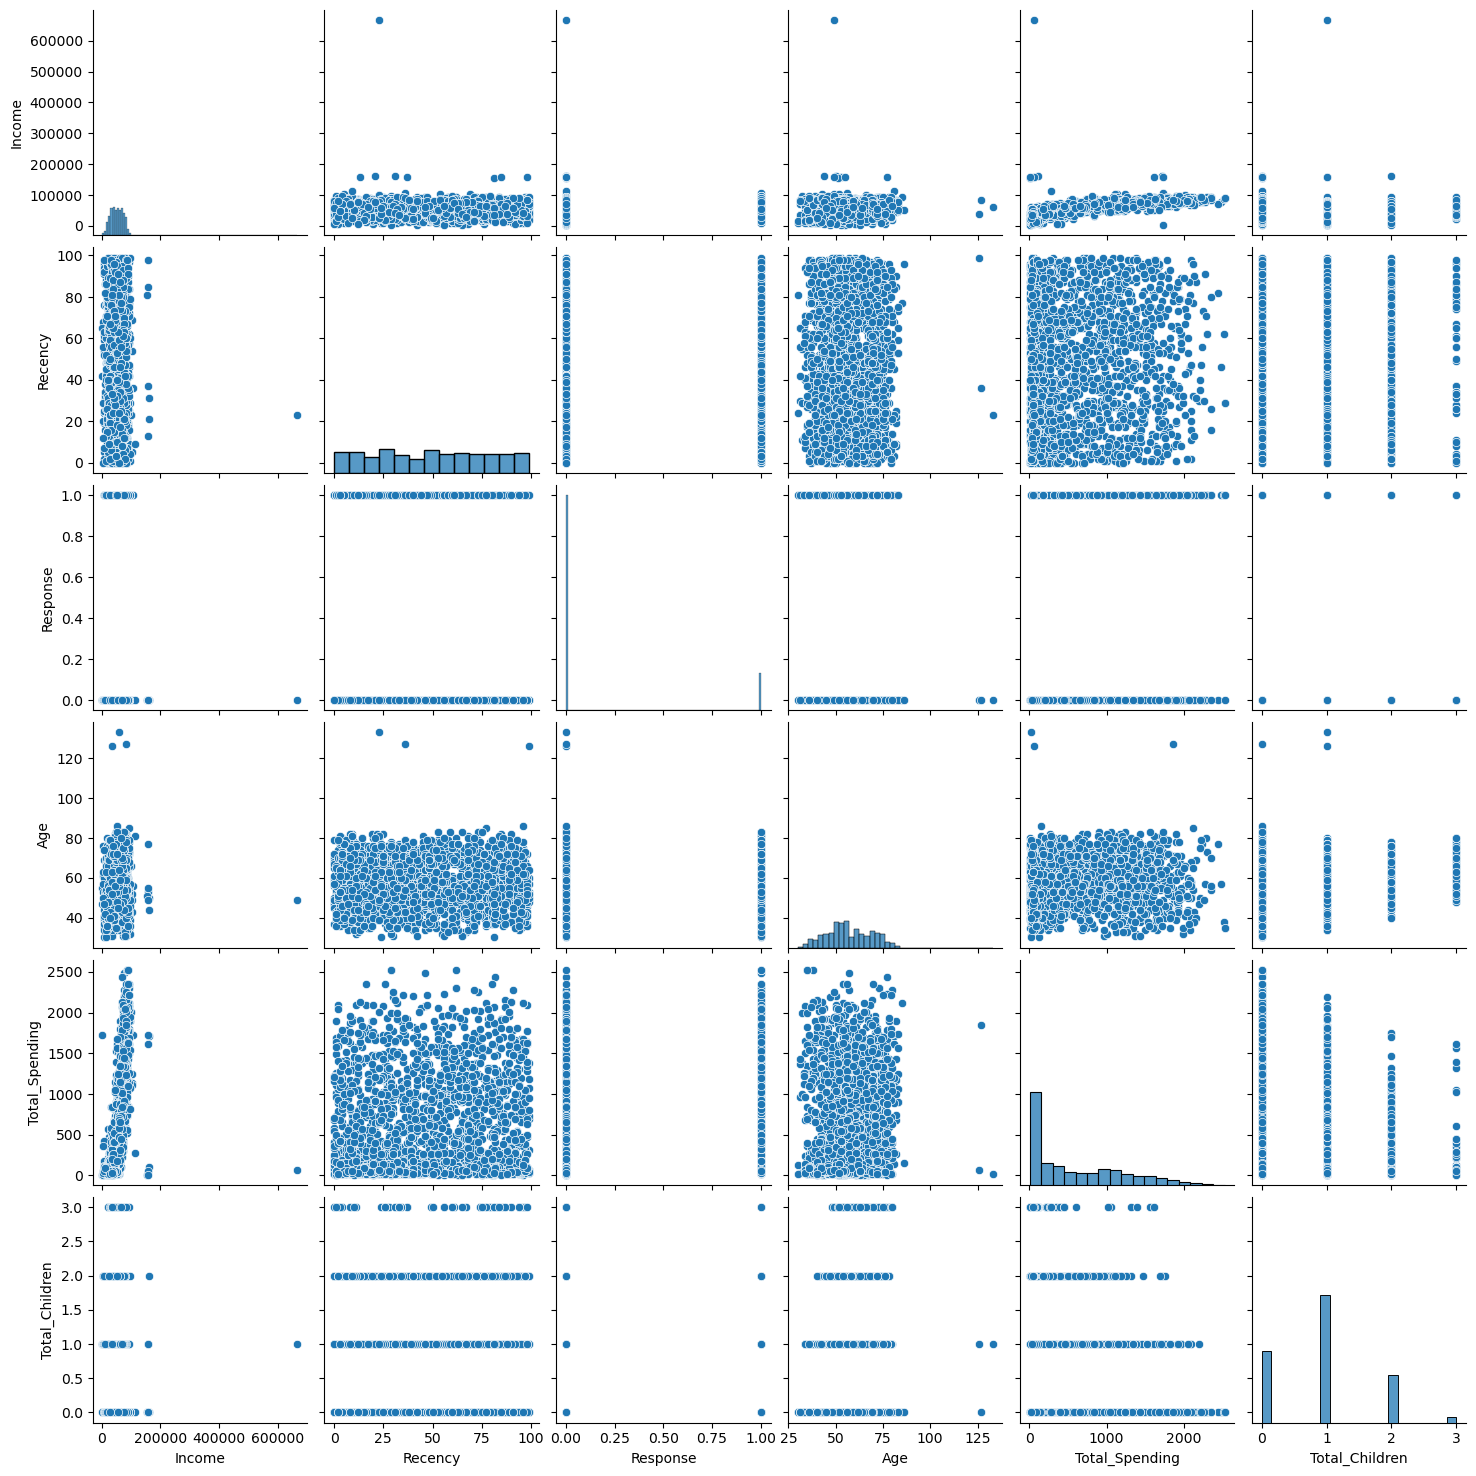

In [12]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Relative plot of some features - pair plots

sns.pairplot(df_cleaned [cols])

### Observation - 

- Outlier 1 => Income Above 600000 is an outlier which wiil affect in clustering
- Outlier 2 => AGE  120 seems wrong input 

In [13]:
# Remove Outliers

print("data size with outliers : ", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90 )]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000 )]

print("data size with0ut outliers : ", len(df_cleaned))

data size with outliers :  2240
data size with0ut outliers :  2236


## ---- Exploratary Data Analysis ----

In [14]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='str')

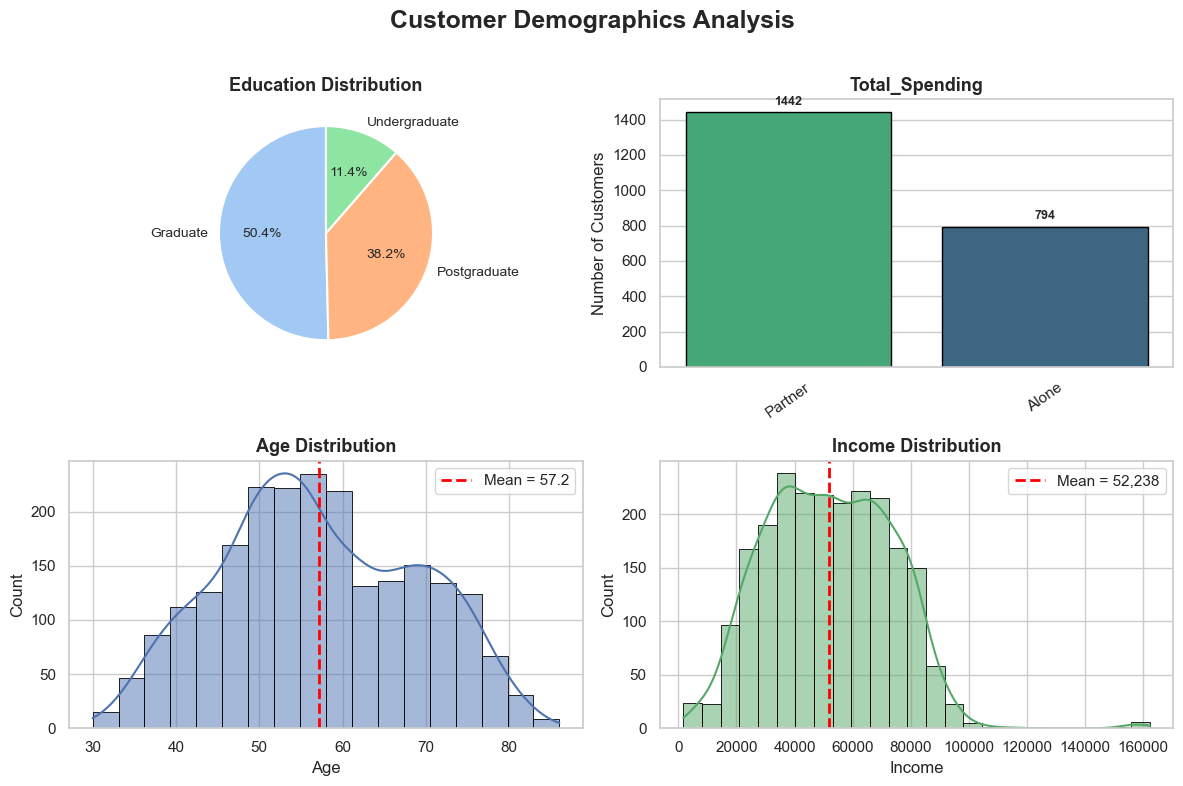

In [15]:
# Customer Demographics

sns.set_theme(style="whitegrid", palette="Set2")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Customer Demographics Analysis", fontsize=18, fontweight="bold")


# Education Pie Chart

education = df_cleaned["Education"].value_counts()

colors = sns.color_palette("pastel")

axes[0,0].pie(
    education,
    labels=education.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor":"white","linewidth":1.5},
    textprops={"fontsize":10}
)

axes[0,0].set_title("Education Distribution", fontsize=13, fontweight="bold")


# Marital Status Countplot

sns.countplot(
    data=df_cleaned,
    x="Living_With",
    hue="Living_With",
    order=df["Living_With"].value_counts().index,
    palette="viridis",
    legend=False,
    edgecolor="black",
    linewidth=1,
    ax=axes[0,1]
)

axes[0,1].set_title("Total_Spending", fontsize=13, fontweight="bold")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Number of Customers")
axes[0,1].tick_params(axis='x', rotation=35)

for container in axes[0,1].containers:
    axes[0,1].bar_label(container, padding=3, fontsize=9, fontweight="bold")


# Age Histogram

sns.histplot(
    df_cleaned["Age"],
    bins=18,
    kde=True,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6,
    ax=axes[1,0]
)

axes[1,0].set_title("Age Distribution", fontsize=13, fontweight="bold")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Count")

# Mean Age Line
axes[1,0].axvline(
    df["Age"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Age'].mean():.1f}"
)
axes[1,0].legend()


# Income Histogram

sns.histplot(
    df_cleaned["Income"],
    bins=25,
    kde=True,
    color="#55A868",
    edgecolor="black",
    linewidth=0.6,
    ax=axes[1,1]
)

axes[1,1].set_title("Income Distribution", fontsize=13, fontweight="bold")
axes[1,1].set_xlabel("Income")
axes[1,1].set_ylabel("Count")

# Mean Income Line
axes[1,1].axvline(
    df_cleaned["Income"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Income'].mean():,.0f}"
)
axes[1,1].legend()

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

## Observation :

- The dataset is dominated by well-educated customers, with Graduates representing the largest segment.
- Married and partnered individuals make up the majority of customers.
- The customer age is concentrated around 50–60 years, indicating a predominantly middle-aged customer base.


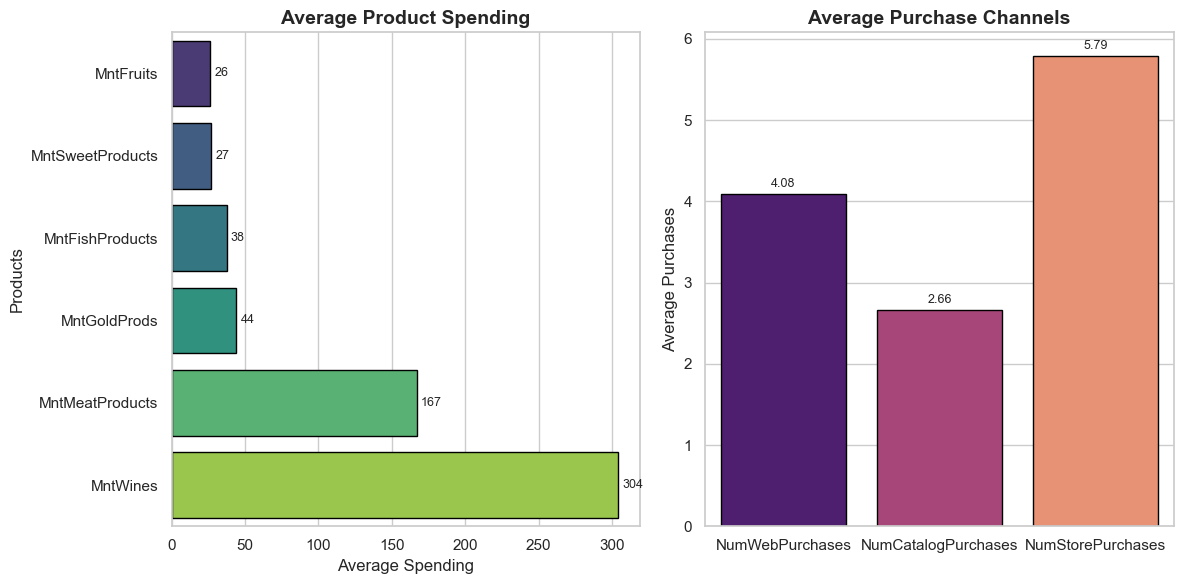

In [16]:
# Customer Spending - old df

fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Average Product Spending


avg_spending = df[spending_cols].mean().sort_values()

sns.barplot(
    x=avg_spending.values,
    y=avg_spending.index,
    hue=avg_spending.index,
    palette="viridis",
    legend=False,
    edgecolor="black",
    linewidth=1,
    ax=axes[0]
)

axes[0].set_title("Average Product Spending", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Average Spending")
axes[0].set_ylabel("Products")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)



# Average Purchase Channels

purchase = df[
    [
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases"
    ]
].mean()

sns.barplot(
    x=purchase.index,
    y=purchase.values,
    hue=purchase.index,
    palette="magma",
    legend=False,
    edgecolor="black",
    linewidth=1,
    ax=axes[1]
)

axes[1].set_title("Average Purchase Channels", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average Purchases")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3, fontsize=9)


plt.tight_layout()
plt.show()

### Observation

- **Wine products (MntWines)** have the highest average customer spending (≈304), making them the most valuable product category.
- **Meat products (MntMeatProducts)** rank second in average spending (≈167), while spending on gold, fish, sweets, and fruits is significantly lower.
- Among the remaining categories, **Gold Products**, **Fish Products**, **Sweet Products**, and **Fruits** show relatively similar and much lower average spending compared to wine and meat.
- Customers make the highest number of purchases through **physical stores** (≈5.79 purchases), indicating that in-store shopping is the preferred purchase channel.
- **Web purchases** (≈4.08) are the second most preferred shopping method, suggesting a moderate adoption of online shopping.
- **Catalog purchases** (≈2.66) have the lowest average, indicating that this channel is the least popular among customers.
- Overall, customers exhibit a stronger preference for purchasing **wine and meat products**, while **physical stores remain the dominant sales channel**.



Text(0.5, 1.0, 'Campaign Response')

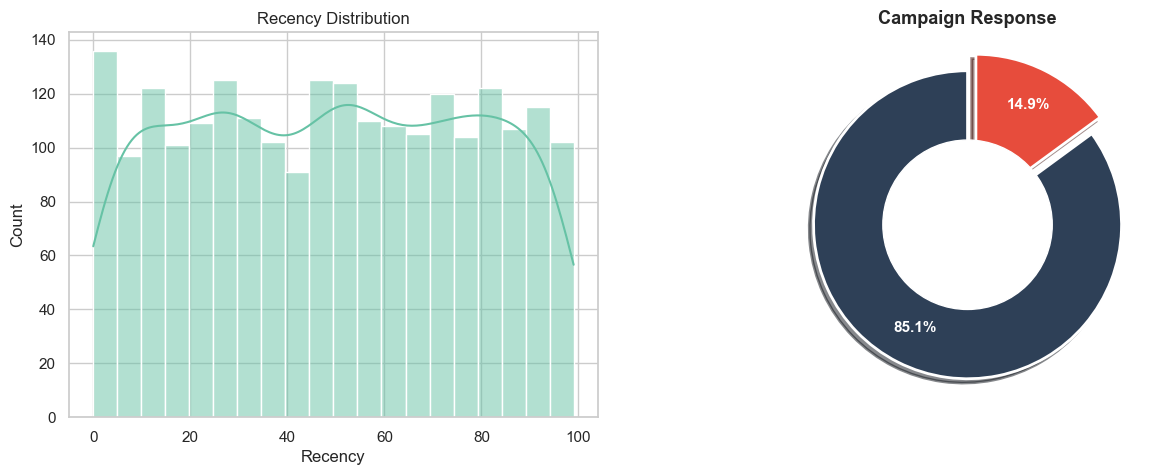

In [17]:
# Customer Behaviour

fig, axes = plt.subplots(1,2, figsize=(15,5))

# Recency

sns.histplot(
    df_cleaned["Recency"],
    kde=True,
    bins=20,
    ax=axes[0]
)

axes[0].set_title("Recency Distribution")

# Response

response = df_cleaned["Response"].value_counts().sort_index()

colors = ["#2E4057", "#E74C3C"]   
explode = (0, 0.12)             

axes[1].pie(
    response,
    labels=["No", "Yes"],
    colors=colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    pctdistance=0.75,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 11,
        "fontweight": "bold",
        "color": "white"
    }
)

centre_circle = plt.Circle((0, 0), 0.55, fc="white")
axes[1].add_artist(centre_circle)

axes[1].set_title(
    "Campaign Response",
    fontsize=13,
    fontweight="bold"
)

## Observation

Customer purchasing recency is well distributed across the dataset, while the marketing campaign achieved a relatively low success rate, with only 14.9% of customers responding positively. This suggests that future customer segmentation could help identify groups that are more likely to respond to targeted marketing campaigns.

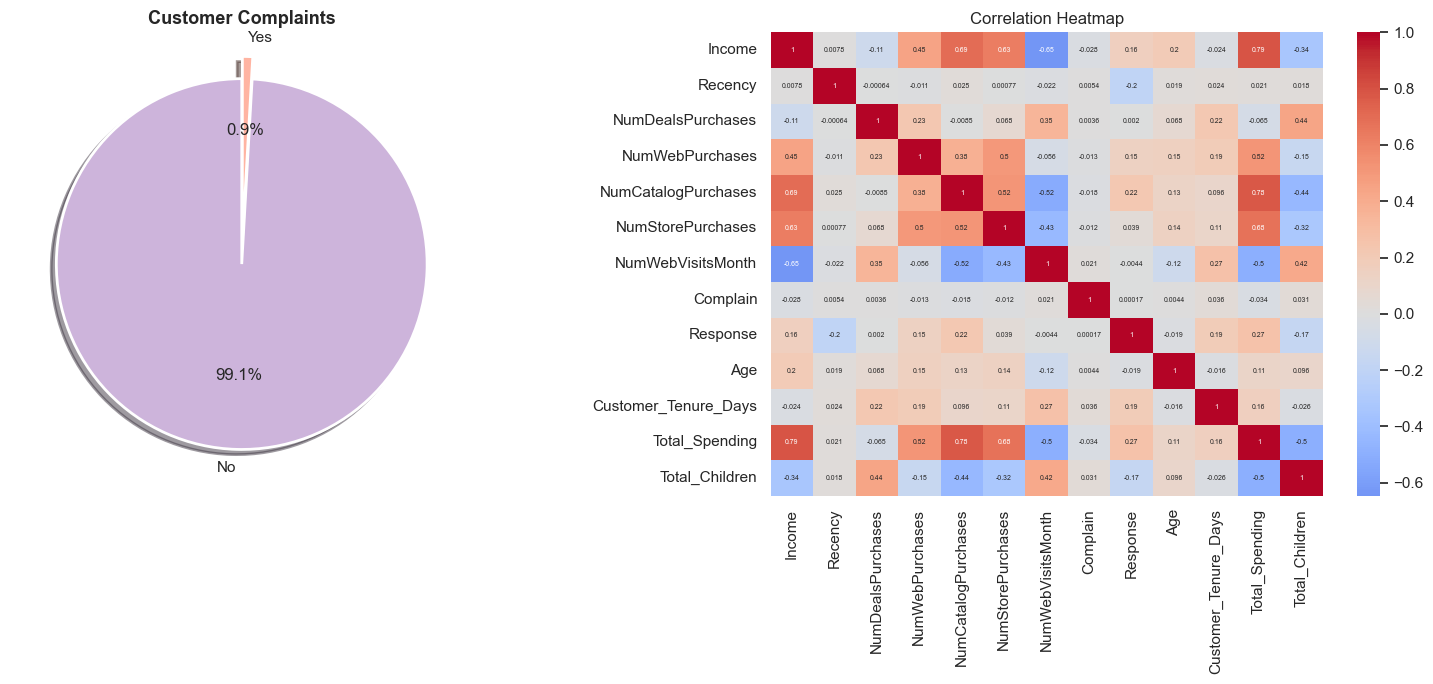

In [18]:
# Complaint & Correlation

fig, axes = plt.subplots(1,2, figsize=(16,7))

# Complaints
complaint = df_cleaned["Complain"].value_counts().sort_index()

axes[0].pie(
    complaint,
    labels=["No", "Yes"],
    colors=["#CDB4DB", "#FFB4A2"],
    explode=(0, 0.12),
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[0].set_title("Customer Complaints", fontsize=13, fontweight="bold")

# Correlation

numeric_df = df_cleaned.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot =True,
    annot_kws ={"size" : 5 },
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)

axes[1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Observation

- The complaint distribution is highly imbalanced, with approximately **99.1%** of customers reporting no complaints and only **0.9%** reporting complaints, indicating a generally high level of customer satisfaction.
- The correlation heatmap reveals that most numerical features have **weak to moderate correlations**, suggesting that they capture different aspects of customer behavior.
- **Income** shows a strong positive correlation with **Total Spending**, indicating that customers with higher incomes tend to spend more overall.
- Purchase channels (**Web, Catalog, and Store Purchases**) exhibit moderate positive correlations with one another, suggesting that active customers tend to shop through multiple channels.
- **NumWebVisitsMonth** has a negative correlation with purchase-related features, implying that customers who visit the website more frequently do not necessarily make more purchases.
- The **Complaint** feature has very weak correlations with the remaining variables, indicating that complaints are largely independent of other customer characteristics.
- Overall, no significant multicollinearity is observed among the numerical features, making the dataset suitable for clustering and further machine learning analysis.rity or unusual correlation patterns are observed, and since Complaint is a binary feature, outliers are not applicable. Overall, the dataset appears well-suited for clustering after standard preprocessing.

## ---------Feature Encoding -------

In [19]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [20]:
ohe = OneHotEncoder()  # DropFirstcol is not used as clustering doesnt have Collinearity prlbm
cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

#convert enc_cols into df 
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index= df_cleaned.index)

# Concat into df_cleaned

df_encoded = pd.concat([ df_cleaned.drop(columns = cat_cols), enc_df], axis=1)
df_encoded.shape

(2236, 18)

In [21]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## ---------- Scaling with Standard Scaler ------------

In [22]:
X = df_encoded

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(2236, 18)

##  -------Visualizing with PCA --------

PCA Variance Dist =>   [0.23163158 0.11385454]


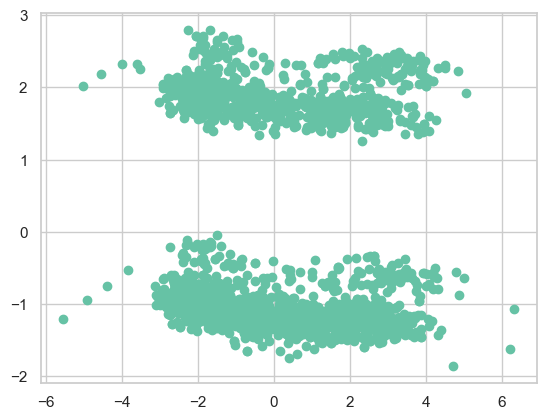

In [23]:
# for 2D

pca2 = PCA(n_components = 2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1]
)

print ("PCA Variance Dist =>  ",pca2.explained_variance_ratio_)

- Almost 34% variance is captured which is SLightly less coz we convert !8f -> 2f (which results in major info lost) 
- To Achieve it better we increase Feature with PCA

PCA Variance Dist for 3D =>   [0.23163158 0.11385454 0.10405815]


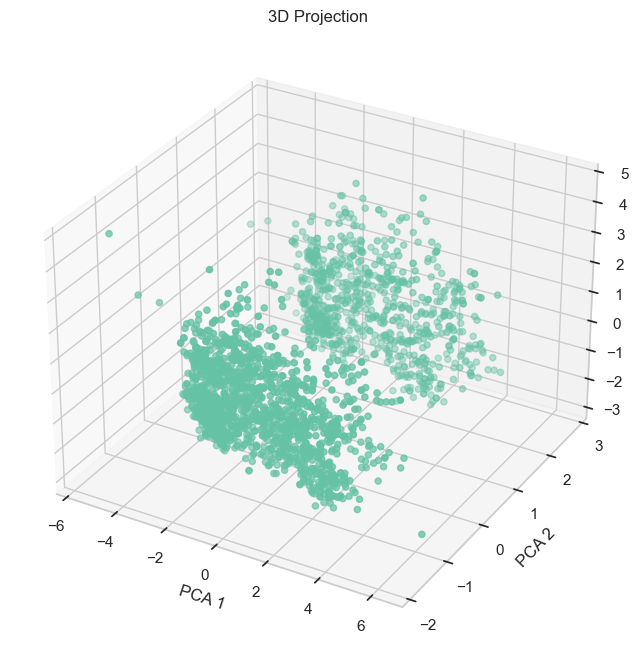

In [24]:
# for 3D

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)


fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D Projection")

print ("PCA Variance Dist for 3D =>  ", pca.explained_variance_ratio_)

## -----Model Training using Kmean, Heirarchical, DBSCAN-------

best k val = 4


Text(0, 0.5, 'WCSS')

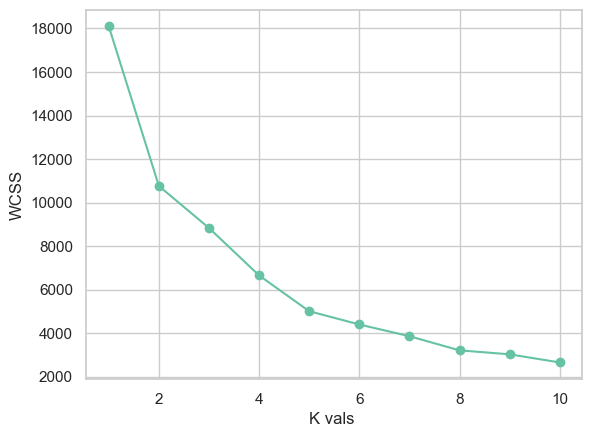

In [25]:
# Analyze K val using elbow method, Silhouette score


# Elbow method for k
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

print("best k val =", optimal_k)


# plot - elbow method
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K vals ")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

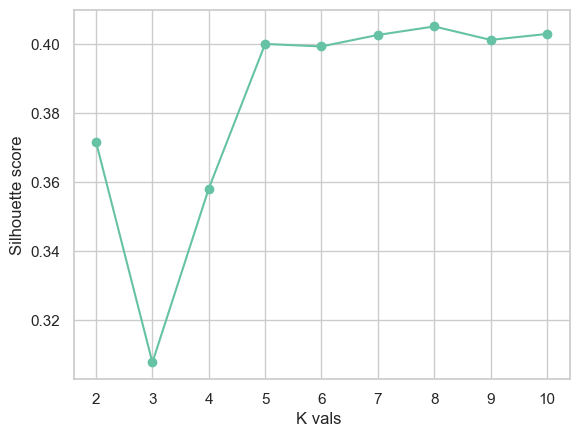

In [26]:
# Silhouetter score for k

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K vals ")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

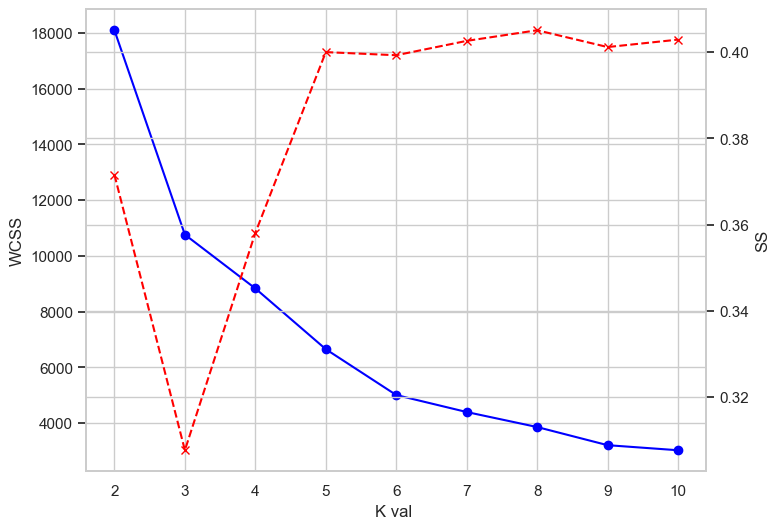

In [27]:
# combined plot - elbow method, Silhouette score

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K val ")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

## ----Clustering Algo ----

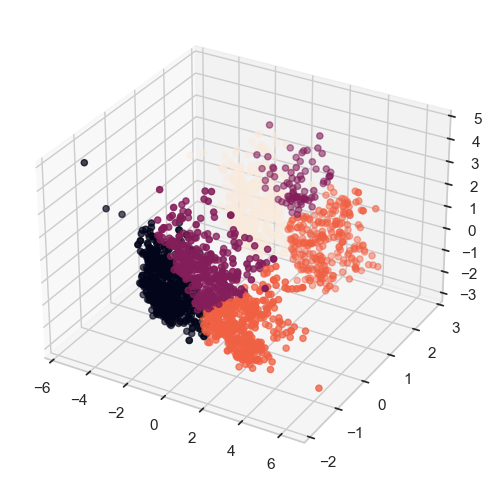

In [28]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

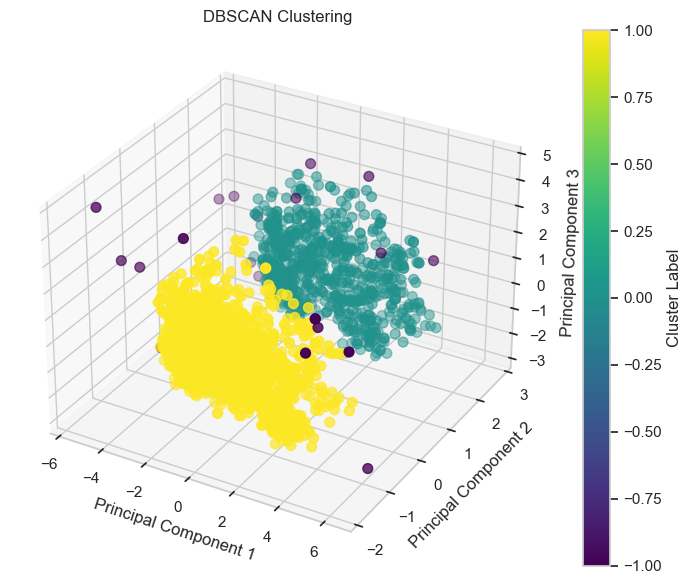

Number of clusters: 2
Number of noise points: 21


In [29]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.7, min_samples=5)

labels_dbscan = dbscan.fit_predict(X_pca)

# 3D Visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=labels_dbscan,
    cmap="viridis",
    s=50
)

ax.set_title("DBSCAN Clustering")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.colorbar(scatter, ax=ax, label="Cluster Label")
plt.tight_layout()
plt.show()


n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

- DBSCAN did not perform as effectively as Agglomerative Clustering because the PCA-transformed customer data formed compact, well-defined clusters with relatively similar densities. As a density-based algorithm, DBSCAN is more suitable for datasets containing irregularly shaped clusters or substantial noise. Consequently, Agglomerative Clustering provided clearer cluster separation and more meaningful customer segmentation for this dataset.

Agglomerative Silhouette Score: 0.379


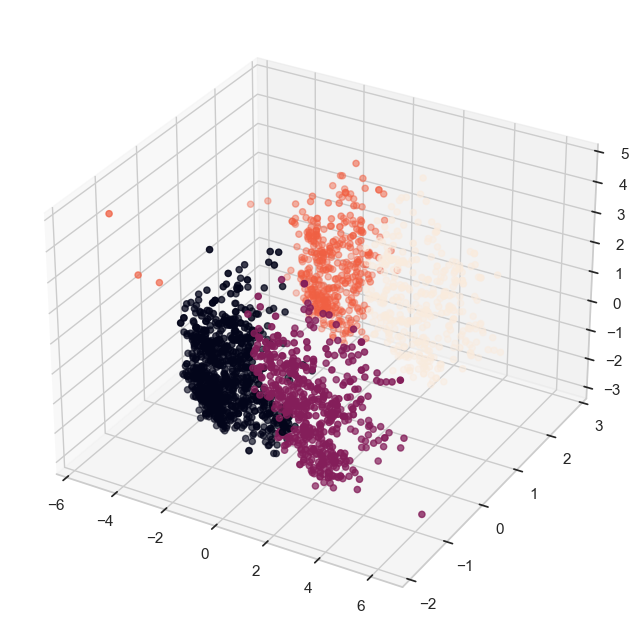

In [30]:
# # Agglomerative Clustering (hierarchical Clustering)

# agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
# labels_agg = agg_clf.fit_predict(X_pca)


# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection="3d")
# ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)


# Agglomerative Clustering (Hierarchical Clustering)

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

# Evaluate Final Model
agg_score = silhouette_score(X_pca, labels_agg)
print(f"Agglomerative Silhouette Score: {agg_score:.3f}")

# 3D Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

## Final Model Evaluation

Agglomerative Clustering achieved a Silhouette Score of **0.379**, indicating good cluster cohesion and separation.

The 3D PCA visualization also showed better-separated and more compact clusters compared to K-Means and DBSCAN. Based on both the quantitative evaluation (Silhouette Score) and the qualitative visualization, Agglomerative Clustering was selected as the final clustering model.

## ------Profiling ---- (Characterization of Cluster)

In [31]:
X["cluster"] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

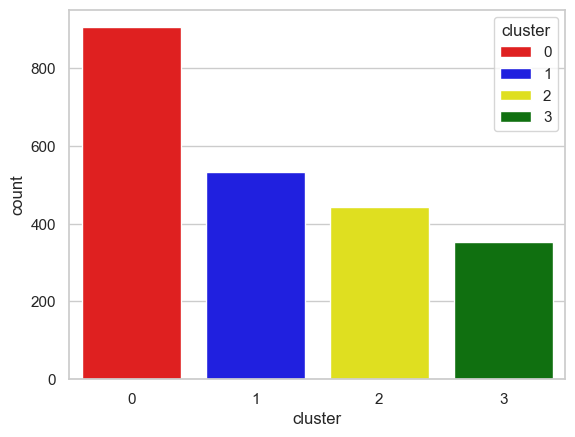

In [32]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(
     x=X["cluster"],
    palette=pal,
    hue=X["cluster"]
)

- Various Values Come under Cluster 1 

<Axes: xlabel='Total_Spending', ylabel='Income'>

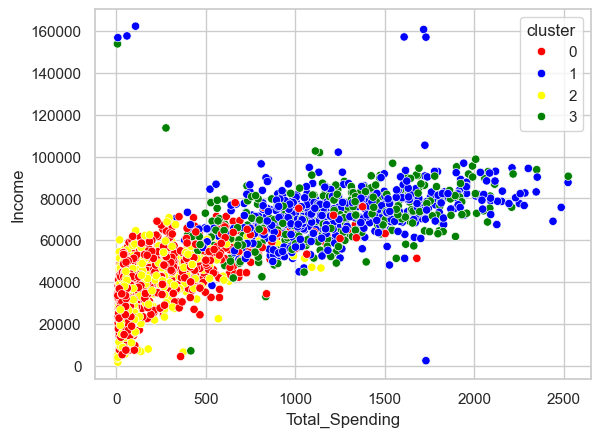

In [33]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

### Observation

- Cluster **0 (Red)** consists of customers with **low to moderate income** and **low spending**.
- Cluster **1 (Blue)** contains customers with the **highest spending** and generally **higher income**, representing high-value customers.
- Cluster **2 (Yellow)** groups customers with **very low spending** despite having varying income levels.
- Cluster **3 (Green)** represents customers with **moderate to high spending** and **moderate income**.
- A positive relationship is observed between **Income** and **Total Spending**, as higher-income customers generally spend more.
- A few **outliers** with exceptionally high income are visible across different clusters.


In [34]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

In [35]:
# Customer Segment Profile
summary = X.groupby("cluster")[
    [
        "Income",
        "Total_Spending",
        "NumWebPurchases",
        "NumStorePurchases",
        "NumCatalogPurchases",
        "Age",
        "Total_Children"
    ]
].mean().round(2)

display(summary)

,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,Age,Total_Children
cluster,,,,,,,
0,39680.58,221.96,3.15,4.14,0.97,55.67,1.24
1,72808.45,1236.59,5.69,8.66,5.50,59.49,0.51
2,36960.14,165.70,2.71,3.62,0.84,55.69,1.27
3,70722.68,1190.39,5.79,8.43,5.01,58.93,0.46


### Cluster Interpretation

- **Cluster 0 (Family Shoppers):** This cluster represents **low-income, low-spending customers**. They make fewer purchases across all channels and generate the lowest overall value, making them budget-conscious or occasional buyers.

- **Cluster 1 (Loyal Customers ):** This is the **best-performing cluster**. Customers have the **highest average income (≈72,808)** and the **highest total spending (≈1,237)**. They actively purchase through web, catalog, and physical stores, making them the most valuable and loyal customer segment.

- **Cluster 2 (Target for Sales) :** This cluster also consists of **low-income customers**, but with the **lowest average spending (≈166)**. They make relatively few purchases and represent inactive or infrequent buyers who can be re-engaged through targeted promotions and personalized marketing campaigns.

- **Cluster 3(Best ROI) :** This cluster is the **second-best performing segment**. Customers have **high income (≈70,723)** and **high total spending (≈1,190)**, with strong purchasing activity across all sales channels.They are valuable customers with strong purchasing behavior, although their overall spending is slightly lower than Cluster 1.

---
### Cluster 0 – Family Shoppers

- Business Recommendation: Offer family bundles, seasonal discounts, and combo offers to increase basket size.

### Cluster 1 – Loyalty Customers

- Business Recommendation: Reward with loyalty points, exclusive offers, and early access to new products to improve retention.

### Cluster 2 – Target for Sales

- Business Recommendation: Use personalized promotions, cross-selling, and targeted marketing campaigns to increase purchase frequency.

### Cluster 3 – Best ROI

- Business Recommendation: Provide VIP benefits, premium membership, and personalized recommendations to maximize customer lifetime value.

---
### Overall Conclusion

**Cluster 1** is the most valuable customer segment because it has the **highest income, highest spending, and the greatest purchasing activity** across multiple channels. **Cluster 3** also represents high-value customers but performs slightly below Cluster 1. In contrast, **Clusters 0 and 2** consist of lower-value customers with lower income and spending, making them suitable targets for engagement and marketing campaigns.

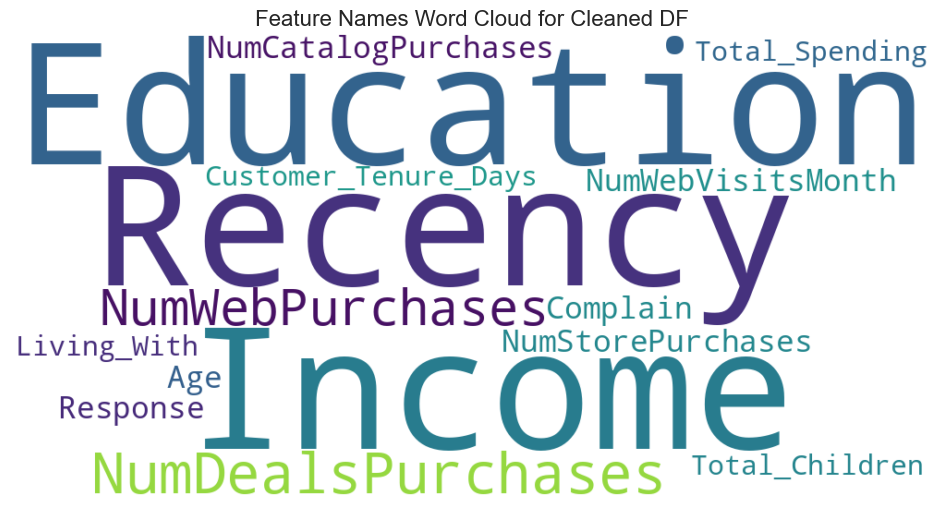

In [36]:
# Word Cloud of Feature Names for cleaned df

feature_text = " ".join(df_cleaned.columns)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate(feature_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Feature Names Word Cloud for Cleaned DF", fontsize=16)
plt.show()